# 03. AI 확장 실험 — 파운데이션 모델 임베딩으로 피크(이상) 위험 확률 높이기

`02_AI예측모델개발.ipynb`의 피크 위험 확률 모델(평가지표의 '제조 이상 확률')은 사람이 설계한 피처(직전 값, 4주 평균, 생산계획 등)로 LightGBM 분류기를 학습했습니다. 이 노트북은 여기에 **사전학습 AI가 스스로 뽑은 특징**을 더하면 피크를 더 잘 맞히는지 확인하는 추가 실험입니다.

- **임베딩**: 시계열 파운데이션 모델 Chronos-2는 수많은 시계열로 미리 학습되어, 과거 전력값을 넣으면 그 흐름을 768개 숫자의 '요약 벡터'로 바꿔 줍니다. 사람이 미리 정하지 않은 패턴(가동 리듬, 기동 직전의 모양 등)까지 담길 수 있습니다.
- **하이브리드 모델**: 이 벡터를 16차원으로 줄여(PCA) 기존 피처와 함께 분류기에 넣습니다. 'Chronos-2의 표현 + 이 공장 데이터로 학습한 분류기'입니다.
- **같은 조건 비교**: 분류기 설정, 확률 보정(isotonic), 경보 임계값을 STEP 6과 똑같이 두고 입력만 바꿉니다. 이전 fold로 맞춰 다음 fold에 적용하므로 F2~F6에서 평가합니다.

| 변형 | 분류기 입력 |
|---|---|
| (a) 기존 피처 | STEP 6과 같음(재현 확인용) |
| (b) 임베딩 + 시각 | 사람이 만든 피처 없이 임베딩과 시각만 |
| (c) 기존 피처 + 임베딩 | 하이브리드 |

> **테스트 구간 사용 원칙**: 테스트(9/1~9/14)는 STEP 7에서 테스트 전에 정한 규칙으로 최종 모델을 고른 뒤 이미 한 번 평가했습니다. 이 실험은 그 뒤에 한 것이므로 **비교와 판단은 검증 fold로만** 합니다. 테스트 결과는 '테스트 공개 후 추가 실험'으로 참고만 하며, 결과와 상관없이 최종 모델 선정은 바꾸지 않습니다.

계산은 `scripts/ext_embed_peak.py`로 했고(노트북 01의 [코드 P-09]), 이 노트북은 저장된 결과를 불러와 보여 줍니다.

프로젝트 폴더를 찾아 공통 함수를 불러오고, 추가 실험 결과 표(`outputs/tables/X01~X07`)가 있는지 확인합니다. 파일이 없으면 노트북 01의 [코드 P-09]를 먼저 실행해야 합니다.

In [1]:
# [코드 X-01] 경로·공통 함수·결과 표 불러오기
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'power_utils').is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import power_utils as pu
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pu.ensure_dirs()
font = pu.set_korean_font()
T = pu.OUT / 'tables'
names = {'X01': 'X01_embed_peak_scores', 'X02': 'X02_embed_peak_folds', 'X03': 'X03_embed_peak_test',
         'X04': 'X04_embed_peak_bootstrap', 'X05': 'X05_embed_gain', 'X06': 'X06_embed_pca2', 'X07': 'X07_embed_info'}
missing = [n for n in names.values() if not (T / f'{n}.csv').exists()]
assert not missing, f'결과 표가 없습니다: {missing} → 노트북 01의 [코드 P-09] 실행'
X = {k: pd.read_csv(T / f'{n}.csv', encoding='utf-8-sig') for k, n in names.items()}
print(f'프로젝트 루트: {ROOT.name} | 한글 글꼴: {font}')
print('불러온 표:', ', '.join(f"{k}({len(v)}행)" for k, v in X.items()))

프로젝트 루트: hourly_max_pipeline | 한글 글꼴: Malgun Gothic
불러온 표: X01(12행), X02(60행), X03(12행), X04(8행), X05(2행), X06(6073행), X07(2행)


## 1. 임베딩 추출과 누수 검사

임베딩을 몇 개 만들었고 시간이 얼마나 걸렸는지, 누수 검사를 통과했는지 봅니다.
- 트랙 A는 매시 직전까지의 1344시간(8주)을, 트랙 B는 매일 전날 23시까지를 넣었습니다.
- 누수 검사는 세 가지입니다. (1) 문맥이 예측 시점 전에 끝나는지 (2) 예측 시점 이후 값을 난수로 바꿔도 임베딩이 그대로인지(무작위 30개 시점) (3) 같은 시점을 혼자 넣든 다른 시점과 함께 넣든 결과가 같은지(배치 불변).

'배치 불변 최대 차이'가 0에 가까우면 계산 순서와 상관없이 같은 벡터가 나온다는 뜻입니다.

In [2]:
# [코드 X-02] 임베딩 정보와 누수 검사 결과 [표 X-00]
info = X['X07'].set_index('track')
display(info)
for tr, r in info.iterrows():
    print(f"트랙 {tr}: 임베딩 {int(r['임베딩 수']):,}개({int(r['임베딩 원래 차원'])}차원 → PCA {int(r['PCA 차원'])}차원), "
          f"계산 {r['임베딩 계산 시간(초)'] / 60:.1f}분(CPU), 누수 검사 {int(r['누수 검사 표본'])}개 통과, "
          f"배치 불변 최대 차이 {r['배치 불변 최대 차이']:.1e}")

,임베딩 수,임베딩 계산 시간(초),누수 검사 표본,배치 불변 최대 차이,문맥 길이,PCA 차원,임베딩 원래 차원
track,,,,,,,
A,6167,614,30,1.132488e-06,1344,16,1536
B,256,27,30,4.991889e-07,1344,16,1536


트랙 A: 임베딩 6,167개(1536차원 → PCA 16차원), 계산 10.2분(CPU), 누수 검사 30개 통과, 배치 불변 최대 차이 1.1e-06
트랙 B: 임베딩 256개(1536차원 → PCA 16차원), 계산 0.5분(CPU), 누수 검사 30개 통과, 배치 불변 최대 차이 5.0e-07


## 2. 임베딩은 공장 상태를 구분할까?

학습에 앞서, Chronos-2가 만든 벡터에 공장의 상태가 담겨 있는지 눈으로 확인합니다. 테스트 이전 임베딩을 PCA로 2차원에 펼치고 점마다 색을 칠했습니다.
- 왼쪽 그림: 트랙 A, 그날이 가동일인지
- 가운데 그림: 트랙 A, 그 시간이 피크(θ = 8/31까지 상위 5%)였는지
- 오른쪽 그림: 트랙 B, 하루 단위 벡터의 가동 여부

Chronos-2는 이 공장 데이터로 학습한 적이 없습니다. 그런데도 같은 색끼리 모여 있다면, 사람이 알려 주지 않아도 가동 리듬이나 피크 직전의 모양을 구분해 낸다는 뜻입니다.

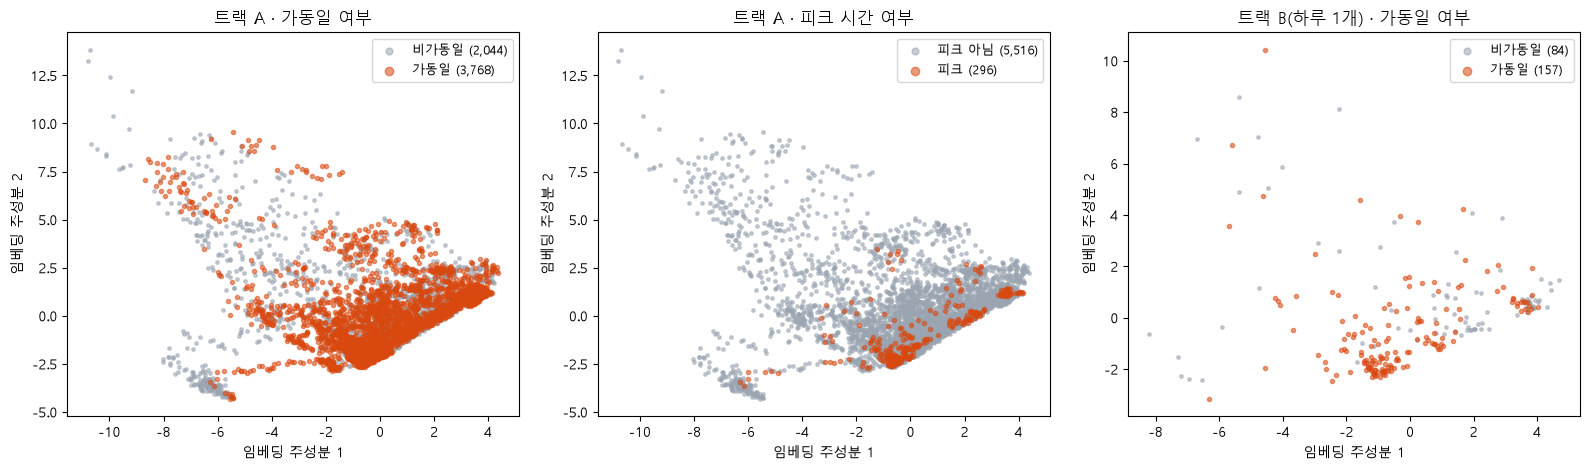

트랙 A op_day별 주성분 평균: False: (-0.24, 0.57) / True: (0.12, -0.31)
트랙 A peak별 주성분 평균: False: (-0.02, 0.05) / True: (0.23, -0.94)
트랙 B op_day별 주성분 평균: False: (0.67, 0.86) / True: (-0.37, -0.46)


In [3]:
# [코드 X-03] 임베딩 2차원 지도 [그림 X-01]
v = X['X06']
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
panels = [('A', 'op_day', '트랙 A · 가동일 여부', {True: '가동일', False: '비가동일'}),
          ('A', 'peak', '트랙 A · 피크 시간 여부', {True: '피크', False: '피크 아님'}),
          ('B', 'op_day', '트랙 B(하루 1개) · 가동일 여부', {True: '가동일', False: '비가동일'})]
for ax, (tr, col, title, lab) in zip(axes, panels):
    d = v[(v['track'] == tr) & ~v['outage']]
    for val, color, size in [(False, '#9aa5b1', 6), (True, '#d9480f', 9)]:
        s = d[d[col] == val]
        ax.scatter(s['pc1'], s['pc2'], s=size, c=color, alpha=0.55, label=f'{lab[val]} ({len(s):,})')
    ax.set_title(title); ax.set_xlabel('임베딩 주성분 1'); ax.set_ylabel('임베딩 주성분 2')
    ax.legend(loc='upper right', fontsize=9, markerscale=2)
fig.tight_layout()
pu.save_fig(fig, 'X01_embed_pca2'); plt.show()
for tr, col in [('A', 'op_day'), ('A', 'peak'), ('B', 'op_day')]:
    d = v[(v['track'] == tr) & ~v['outage']]
    g = d.groupby(col)[['pc1', 'pc2']].mean().round(2)
    print(f'트랙 {tr} {col}별 주성분 평균: ' + ' / '.join(f"{k}: ({r.pc1}, {r.pc2})" for k, r in g.iterrows()))

## 3. 핵심 비교 — 임베딩을 더하면 피크를 더 잘 맞히나

변형 (a)·(b)·(c)를 같은 조건에서 비교합니다(F2~F6 평균). 두 경로를 봅니다.
- **분류기**: 분류기 확률을 isotonic으로 보정한 경보
- **스태킹**: 분위수 확률 + 분류기 확률 + 점예측을 결합한 경보. 트랙 A의 최종 경보 경로입니다. 트랙 B의 최종 경보는 분류기입니다.

지표 읽는 법:
- F1·PR-AUC는 높을수록, Brier·ECE는 낮을수록 좋습니다.
- (a)가 STEP 6 값(분류기 F1 A 0.757·B 0.676, 스태킹 F1 A 0.785·B 0.674)과 같으면 비교 조건이 STEP 6과 같다는 확인이 됩니다.

In [4]:
# [코드 X-04] 변형별 피크 위험 확률 성능(F2~F6) [표 X-01]
s = X['X01'].rename(columns={'f1': 'F1', 'precision': '정밀도', 'recall': '재현율', 'pr_auc': 'PR-AUC',
                             'brier': 'Brier', 'ece': 'ECE', 'variant': '변형', 'path': '경로'})
for tr in ['A', 'B']:
    print(f'[표 X-01] 트랙 {tr} — 피크 위험 확률 성능(F2~F6 평균, 이전 fold로 보정·임계값)')
    display(s[s['track'] == tr].drop(columns='track').reset_index(drop=True).round(4))
s6 = pd.read_csv(T / 'step6_classification.csv', encoding='utf-8-sig')
s6 = s6[(s6['label'] == '단순 피크') & (s6['rule'] == 'F1 최대')].groupby(['track', 'path'])['f1'].mean()
for tr in ['A', 'B']:
    for p6, px in [('경로2 분류기(가중)', '분류기'), ('스태킹', '스태킹')]:
        a = s.loc[(s['track'] == tr) & (s['변형'] == '(a) 기존 피처') & (s['경로'] == px), 'F1'].iloc[0]
        print(f'재현 확인 트랙 {tr} {px}: (a) F1 {a:.4f} vs STEP 6 {s6[(tr, p6)]:.4f} → '
              f"{'일치' if abs(a - s6[(tr, p6)]) < 1e-3 else '불일치'}")

[표 X-01] 트랙 A — 피크 위험 확률 성능(F2~F6 평균, 이전 fold로 보정·임계값)


,변형,경로,F1,정밀도,재현율,PR-AUC,Brier,ECE
0,(a) 기존 피처,분류기,0.7568,0.6938,0.8465,0.7823,0.0497,0.0456
1,(a) 기존 피처,스태킹,0.7845,0.7505,0.8392,0.8012,0.0450,0.0352
2,(b) 임베딩 + 시각,분류기,0.6376,0.5710,0.7814,0.5934,0.0798,0.0660
3,(b) 임베딩 + 시각,스태킹,0.7368,0.7542,0.7685,0.8010,0.0468,0.0365
4,(c) 기존 피처 + 임베딩,분류기,0.7356,0.6943,0.8268,0.7408,0.0535,0.0551
5,(c) 기존 피처 + 임베딩,스태킹,0.7586,0.7581,0.7980,0.7672,0.0481,0.0451


[표 X-01] 트랙 B — 피크 위험 확률 성능(F2~F6 평균, 이전 fold로 보정·임계값)


,변형,경로,F1,정밀도,재현율,PR-AUC,Brier,ECE
0,(a) 기존 피처,분류기,0.6763,0.5845,0.8222,0.6154,0.0708,0.0491
1,(a) 기존 피처,스태킹,0.6742,0.6153,0.7820,0.6483,0.0687,0.0478
2,(b) 임베딩 + 시각,분류기,0.6308,0.5493,0.7830,0.5844,0.0778,0.0570
3,(b) 임베딩 + 시각,스태킹,0.6355,0.5705,0.7812,0.6655,0.0650,0.0562
4,(c) 기존 피처 + 임베딩,분류기,0.6396,0.5596,0.7791,0.5595,0.0786,0.0583
5,(c) 기존 피처 + 임베딩,스태킹,0.6529,0.6100,0.7470,0.6435,0.0697,0.0456


재현 확인 트랙 A 분류기: (a) F1 0.7568 vs STEP 6 0.7568 → 일치
재현 확인 트랙 A 스태킹: (a) F1 0.7845 vs STEP 6 0.7845 → 일치
재현 확인 트랙 B 분류기: (a) F1 0.6763 vs STEP 6 0.6763 → 일치
재현 확인 트랙 B 스태킹: (a) F1 0.6742 vs STEP 6 0.6742 → 일치


## 4. 차이가 우연은 아닐까 — 부트스트랩 신뢰구간

F2~F6의 시간별 결과를 **하루 단위로 묶어 여러 번 다시 뽑아**(2000회) 차이의 95% 신뢰구간을 구합니다. 같은 날의 시간끼리는 비슷하게 움직이므로 하루 단위로 묶습니다.
- F1 차이: 변형 − 기존(a). 신뢰구간이 0보다 위에 있으면 유의한 개선입니다.
- Brier 차이: 변형 − 기존(a). 낮을수록 좋은 지표이므로, 신뢰구간이 0보다 아래에 있으면 유의한 개선입니다.
- 신뢰구간이 0을 포함하면 차이가 우연일 수 있습니다(동등).

In [5]:
# [코드 X-05] 변형 − 기존(a) 차이의 95% 신뢰구간 [표 X-02]
b = X['X04'].copy()
f1d = X['X01'].pivot_table(index=['track', 'path'], columns='variant', values='f1')
b['F1 차이(변형−기존)'] = [f1d.loc[(r.track, r.path), r.variant] - f1d.loc[(r.track, r.path), '(a) 기존 피처']
                       for r in b.itertuples()]
def verdict(lo, hi, better_if_positive):
    if lo > 0: return '개선' if better_if_positive else '악화'
    if hi < 0: return '악화' if better_if_positive else '개선'
    return '차이 없음(우연 범위)'
b['F1 판정'] = [verdict(r['F1 차이 95% CI 하한'], r['F1 차이 95% CI 상한'], True) for _, r in b.iterrows()]
b['Brier 판정'] = [verdict(r['Brier 차이 95% CI 하한'], r['Brier 차이 95% CI 상한'], False) for _, r in b.iterrows()]
cols = ['track', 'variant', 'path', 'F1 차이(변형−기존)', 'F1 차이 95% CI 하한', 'F1 차이 95% CI 상한', 'F1 판정',
        'Brier 차이(변형−기존)', 'Brier 차이 95% CI 하한', 'Brier 차이 95% CI 상한', 'Brier 판정']
pu.save_table(b[cols], 'X08_embed_peak_verdict')
display(b[cols].round(4))

,track,variant,path,F1 차이(변형−기존),F1 차이 95% CI 하한,F1 차이 95% CI 상한,F1 판정,Brier 차이(변형−기존),Brier 차이 95% CI 하한,Brier 차이 95% CI 상한,Brier 판정
0,A,(b) 임베딩 + 시각,분류기,-0.1192,-0.1811,-0.0730,악화,0.0300,0.0189,0.0417,악화
1,A,(b) 임베딩 + 시각,스태킹,-0.0477,-0.0820,-0.0069,악화,0.0018,-0.0037,0.0071,차이 없음(우연 범위)
2,A,(c) 기존 피처 + 임베딩,분류기,-0.0212,-0.0593,0.0051,차이 없음(우연 범위),0.0037,-0.0002,0.0076,차이 없음(우연 범위)
3,A,(c) 기존 피처 + 임베딩,스태킹,-0.0259,-0.0530,-0.0031,악화,0.0031,0.0002,0.0062,악화
4,B,(b) 임베딩 + 시각,분류기,-0.0455,-0.0892,0.0134,차이 없음(우연 범위),0.0070,-0.0071,0.0179,차이 없음(우연 범위)
5,B,(b) 임베딩 + 시각,스태킹,-0.0387,-0.0658,0.0111,차이 없음(우연 범위),-0.0038,-0.0140,0.0043,차이 없음(우연 범위)
6,B,(c) 기존 피처 + 임베딩,분류기,-0.0367,-0.0761,0.0074,차이 없음(우연 범위),0.0077,-0.0013,0.0158,차이 없음(우연 범위)
7,B,(c) 기존 피처 + 임베딩,스태킹,-0.0213,-0.0524,0.0216,차이 없음(우연 범위),0.0009,-0.0058,0.0054,차이 없음(우연 범위)


## 5. fold별로 보면

평균만 보면 한두 fold의 큰 차이에 가려질 수 있습니다. 그래서 F2~F6 각각에서 세 변형의 F1을 그립니다.
- 선이 fold마다 엇갈리면 구간에 따라 유불리가 다르다는 뜻입니다.
- (c)가 대부분의 fold에서 (a)보다 위에 있으면 꾸준한 개선입니다.

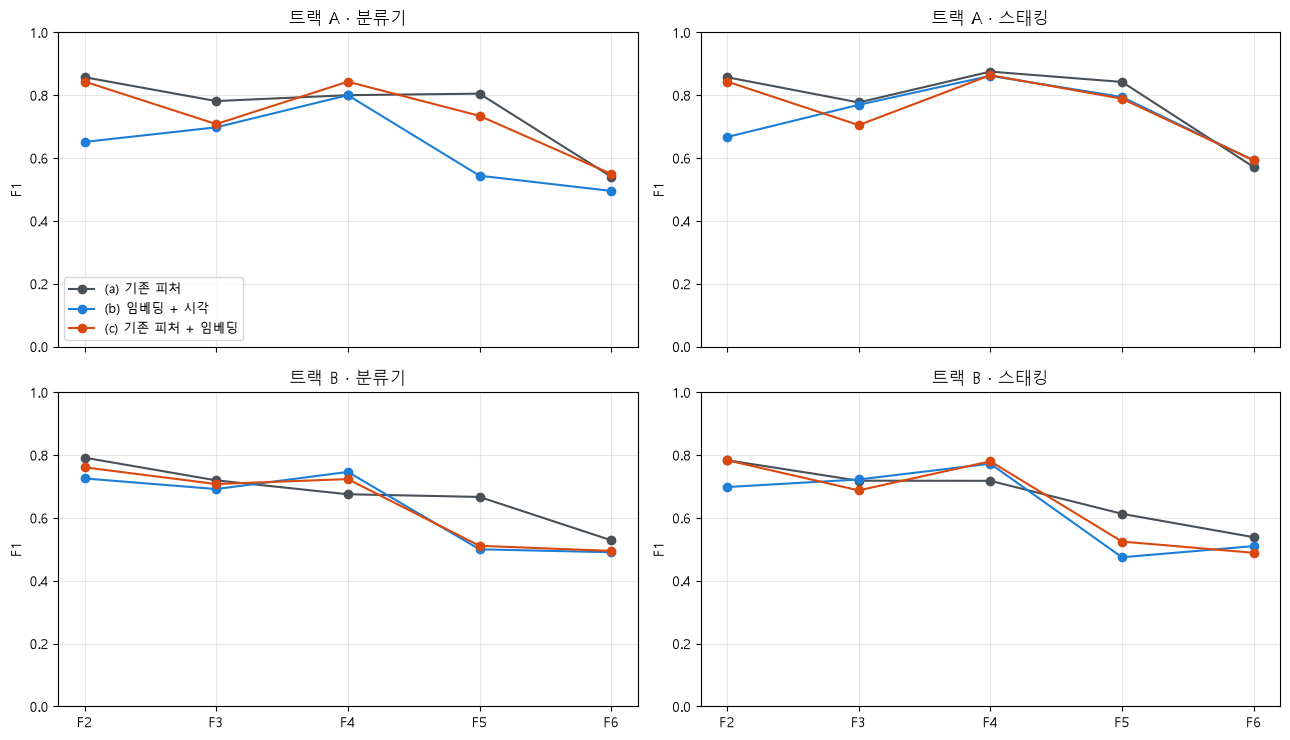

트랙 A 분류기: (c)가 (a)보다 F1이 높은 fold 2/5개
트랙 A 스태킹: (c)가 (a)보다 F1이 높은 fold 1/5개
트랙 B 분류기: (c)가 (a)보다 F1이 높은 fold 1/5개
트랙 B 스태킹: (c)가 (a)보다 F1이 높은 fold 1/5개


In [6]:
# [코드 X-06] fold별 F1 [그림 X-02]
fd = X['X02']
fig, axes = plt.subplots(2, 2, figsize=(13, 7.5), sharex=True)
colors = {'(a) 기존 피처': '#495057', '(b) 임베딩 + 시각': '#1c7ed6', '(c) 기존 피처 + 임베딩': '#d9480f'}
for i, tr in enumerate(['A', 'B']):
    for j, path in enumerate(['분류기', '스태킹']):
        ax = axes[i, j]
        for var, c in colors.items():
            d = fd[(fd['track'] == tr) & (fd['path'] == path) & (fd['variant'] == var)]
            ax.plot(d['fold'], d['f1'], marker='o', color=c, label=var)
        ax.set_title(f'트랙 {tr} · {path}'); ax.set_ylabel('F1'); ax.set_ylim(0, 1); ax.grid(alpha=0.3)
axes[0, 0].legend(loc='lower left', fontsize=9)
fig.tight_layout()
pu.save_fig(fig, 'X02_embed_fold_f1'); plt.show()
w = fd.pivot_table(index=['track', 'path', 'fold'], columns='variant', values='f1')
for (tr, path), g in w.groupby(level=[0, 1]):
    n_up = int((g['(c) 기존 피처 + 임베딩'] > g['(a) 기존 피처']).sum())
    print(f'트랙 {tr} {path}: (c)가 (a)보다 F1이 높은 fold {n_up}/{len(g)}개')

## 6. 확률을 믿을 수 있나 — 신뢰도 곡선

확률을 10구간으로 나눠, 구간마다 '모델이 말한 평균 확률'(가로)과 '실제 피크 비율'(세로)을 찍습니다. 대각선에 가까울수록 '70%'라고 할 때 실제로 약 70%가 피크라는 뜻입니다. 각 트랙의 최종 경보 경로(트랙 A 스태킹, 트랙 B 분류기)로 (a)와 (c)를 비교합니다.

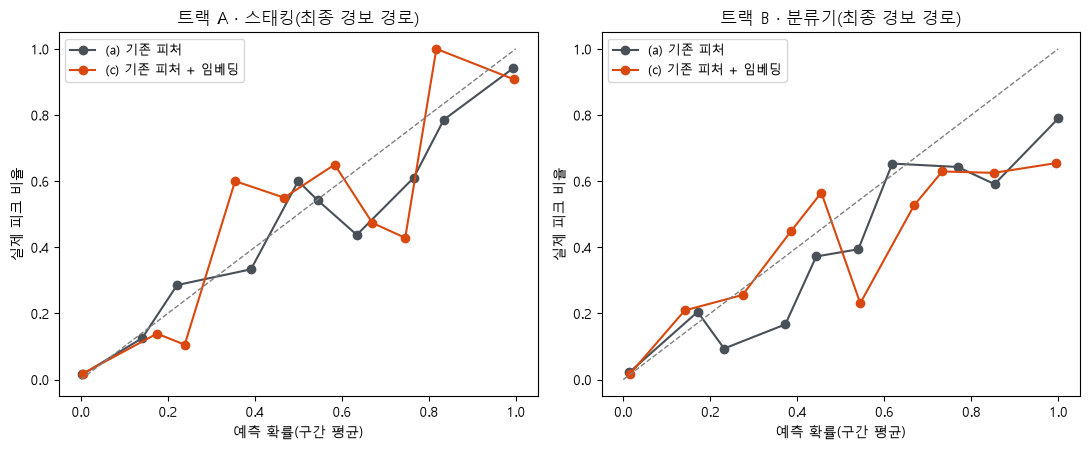

트랙 A 스태킹: ECE (a) 0.0352 → (c) 0.0451, Brier (a) 0.0450 → (c) 0.0481
트랙 B 분류기: ECE (a) 0.0491 → (c) 0.0583, Brier (a) 0.0708 → (c) 0.0786


In [7]:
# [코드 X-07] 신뢰도 곡선: 기존(a) vs 하이브리드(c) [그림 X-03]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
bins = np.linspace(0, 1, 11)
for ax, (tr, path) in zip(axes, [('A', 'stack'), ('B', 'p2')]):
    p = pd.read_parquet(pu.OUT / 'preds' / f'ext_embed_{tr}.parquet')
    p = p[~p['outage']]
    for v, c, name in [('a', '#495057', '(a) 기존 피처'), ('c', '#d9480f', '(c) 기존 피처 + 임베딩')]:
        prob = p[f'p_{v}_{path}']
        g = p.groupby(pd.cut(prob, bins, include_lowest=True), observed=True)
        ax.plot(g[f'p_{v}_{path}'].mean(), g['peak'].mean(), marker='o', color=c, label=name)
    ax.plot([0, 1], [0, 1], ls='--', color='gray', lw=1)
    ax.set_title(f"트랙 {tr} · {'스태킹' if path == 'stack' else '분류기'}(최종 경보 경로)")
    ax.set_xlabel('예측 확률(구간 평균)'); ax.set_ylabel('실제 피크 비율'); ax.legend(fontsize=9)
fig.tight_layout()
pu.save_fig(fig, 'X03_embed_reliability'); plt.show()
s = X['X01']
for tr, path in [('A', '스태킹'), ('B', '분류기')]:
    r = s[(s['track'] == tr) & (s['path'] == path)].set_index('variant')
    print(f"트랙 {tr} {path}: ECE (a) {r.loc['(a) 기존 피처', 'ece']:.4f} → (c) {r.loc['(c) 기존 피처 + 임베딩', 'ece']:.4f}, "
          f"Brier (a) {r.loc['(a) 기존 피처', 'brier']:.4f} → (c) {r.loc['(c) 기존 피처 + 임베딩', 'brier']:.4f}")

## 7. 분류기는 임베딩을 얼마나 썼나

하이브리드 분류기(c)를 8/31까지의 데이터로 학습해, 나무를 나눌 때 줄어든 오차의 합(gain) 중 임베딩 16개 성분이 차지하는 비율을 봅니다. 비율이 크면 분류기가 사람이 만든 피처만으로는 얻지 못한 정보를 임베딩에서 가져갔다는 뜻입니다. 다만 '많이 쓰였다'는 것이 곧 '성능을 올렸다'는 뜻은 아니므로 [표 X-01]과 함께 봅니다.

In [8]:
# [코드 X-08] 하이브리드 분류기의 임베딩 gain 비율 [표 X-03]
g = X['X05'].copy()
g['임베딩 성분 gain 비율'] = (g['임베딩 성분 gain 비율'] * 100).round(1).astype(str) + '%'
display(g)

,track,임베딩 성분 gain 비율,임베딩 상위 성분,전체 상위 5개 피처
0,A,19.9%,emb_14,"y_lag1, q4_lag1, hour, y_lag168, month"
1,B,26.1%,emb_02,"y_d14, y_d7, hour, y_dow4w, y_d1"


## 8. (참고) 테스트 구간 — 테스트 공개 후 추가 실험

STEP 7과 같은 방식으로 적용했습니다. 분류기는 8/31까지의 데이터로 학습하고, 확률 보정·임계값은 6 fold 전체로 맞췄습니다. 이 결과는 **최종 모델 선정에 쓰지 않습니다.**
- 첫 줄의 재현 확인은 (a)가 STEP 7의 테스트 경보와 같은지 봅니다.
- 테스트 피크는 트랙마다 28건뿐이라, 한두 건 차이로도 F1이 크게 움직입니다.

In [9]:
# [코드 X-09] 테스트 공개 후 참고 결과 [표 X-04]
import json
t = X['X03']
print(f"구분: {t['구분'].iloc[0]}")
display(t.drop(columns='구분')[['track', 'variant', 'path', 'f1', 'precision', 'recall', 'pr_auc', 'brier', 'tp', 'fp', 'fn']].round(4))
df, _ = pu.load_data()
for tr, path, col in [('A', '스태킹', 'stack'), ('B', '분류기', 'p2')]:
    al = pd.read_parquet(pu.OUT / 'preds' / f'test_alarm_{tr}.parquet')
    thr = json.load(open(T / f'test_alarm_thresholds_{tr}.json'))[col]
    ok = ~df.loc[al.index, 'outage'].to_numpy()
    lab, alarm = (df.loc[al.index, 'y'] >= al['theta']).to_numpy()[ok], (al[f'p_{col}'] >= thr).to_numpy()[ok]
    tp, fp, fn = (lab & alarm).sum(), (~lab & alarm).sum(), (lab & ~alarm).sum()
    a = t[(t['track'] == tr) & (t['path'] == path) & (t['variant'] == '(a) 기존 피처')]['f1'].iloc[0]
    print(f'재현 확인 트랙 {tr} {path}: STEP 7 테스트 F1 {2 * tp / (2 * tp + fp + fn):.4f} vs (a) {a:.4f}')

구분: 테스트 공개 후 추가 실험(선정에 사용하지 않음)


,track,variant,path,f1,precision,recall,pr_auc,brier,tp,fp,fn
0,A,(a) 기존 피처,분류기,0.5373,0.4615,0.6429,0.5134,0.0569,18,21,10
1,A,(a) 기존 피처,스태킹,0.5672,0.4872,0.6786,0.5449,0.0529,19,20,9
2,A,(b) 임베딩 + 시각,분류기,0.5116,0.3793,0.7857,0.4199,0.0628,22,36,6
3,A,(b) 임베딩 + 시각,스태킹,0.5614,0.5517,0.5714,0.5063,0.0505,16,13,12
4,A,(c) 기존 피처 + 임베딩,분류기,0.5507,0.4634,0.6786,0.4822,0.0561,19,22,9
5,A,(c) 기존 피처 + 임베딩,스태킹,0.5672,0.4872,0.6786,0.5185,0.0544,19,20,9
6,B,(a) 기존 피처,분류기,0.5625,0.3971,0.9643,0.4336,0.0654,27,41,1
7,B,(a) 기존 피처,스태킹,0.5455,0.3803,0.9643,0.4660,0.0688,27,44,1
8,B,(b) 임베딩 + 시각,분류기,0.5047,0.3418,0.9643,0.3874,0.0749,27,52,1
9,B,(b) 임베딩 + 시각,스태킹,0.5234,0.3544,1.0000,0.3808,0.0761,28,51,0


재현 확인 트랙 A 스태킹: STEP 7 테스트 F1 0.5672 vs (a) 0.5672


재현 확인 트랙 B 분류기: STEP 7 테스트 F1 0.5625 vs (a) 0.5625


## 9. 결론

아래 코드는 위 표들의 값을 그대로 인용해 결론 문장을 출력합니다. 숫자를 손으로 옮겨 적지 않기 위해서입니다. 판정 기준은 검증 F2~F6의 부트스트랩 신뢰구간이며, 테스트는 참고로만 씁니다.

In [10]:
# [코드 X-10] 결론 문장(검증 F2~F6 기준)
s, b = X['X01'], pd.read_csv(T / 'X08_embed_peak_verdict.csv', encoding='utf-8-sig')
t = X['X03']
for tr, path in [('A', '스태킹'), ('B', '분류기')]:
    r = s[(s['track'] == tr) & (s['path'] == path)].set_index('variant')
    bv = b[(b['track'] == tr) & (b['path'] == path) & (b['variant'] == '(c) 기존 피처 + 임베딩')].iloc[0]
    tv = t[(t['track'] == tr) & (t['path'] == path)].set_index('variant')['f1']
    print(f"■ 트랙 {tr}(최종 경보 경로 = {path})")
    print(f"  검증 F1: 기존 {r.loc['(a) 기존 피처', 'f1']:.3f} → 하이브리드 {r.loc['(c) 기존 피처 + 임베딩', 'f1']:.3f} "
          f"(임베딩+시각만 {r.loc['(b) 임베딩 + 시각', 'f1']:.3f})")
    print(f"  F1 차이 95% CI [{bv['F1 차이 95% CI 하한']:+.3f}, {bv['F1 차이 95% CI 상한']:+.3f}] → {bv['F1 판정']}; "
          f"Brier 차이 95% CI [{bv['Brier 차이 95% CI 하한']:+.4f}, {bv['Brier 차이 95% CI 상한']:+.4f}] → {bv['Brier 판정']}")
    print(f"  (참고, 테스트 공개 후) 테스트 F1: 기존 {tv['(a) 기존 피처']:.3f} → 하이브리드 {tv['(c) 기존 피처 + 임베딩']:.3f}")
g = X['X05'].set_index('track')['임베딩 성분 gain 비율']
print(f"임베딩 성분 gain 비율: 트랙 A {g['A'] * 100:.1f}%, 트랙 B {g['B'] * 100:.1f}%")

■ 트랙 A(최종 경보 경로 = 스태킹)
  검증 F1: 기존 0.785 → 하이브리드 0.759 (임베딩+시각만 0.737)
  F1 차이 95% CI [-0.053, -0.003] → 악화; Brier 차이 95% CI [+0.0002, +0.0062] → 악화
  (참고, 테스트 공개 후) 테스트 F1: 기존 0.567 → 하이브리드 0.567
■ 트랙 B(최종 경보 경로 = 분류기)
  검증 F1: 기존 0.676 → 하이브리드 0.640 (임베딩+시각만 0.631)
  F1 차이 95% CI [-0.076, +0.007] → 차이 없음(우연 범위); Brier 차이 95% CI [-0.0013, +0.0158] → 차이 없음(우연 범위)
  (참고, 테스트 공개 후) 테스트 F1: 기존 0.562 → 하이브리드 0.505
임베딩 성분 gain 비율: 트랙 A 19.9%, 트랙 B 26.1%


## 10. 해석과 한계

**결과**: 임베딩을 더해도 피크 위험 확률은 좋아지지 않았습니다.
- 트랙 A의 최종 경보 경로(스태킹)에서는 하이브리드 F1이 오히려 유의하게 낮았습니다. F1 차이의 신뢰구간이 0보다 아래([코드 X-10] 출력)입니다.
- 트랙 B는 하이브리드가 낮았지만 신뢰구간이 0을 포함해 우연 범위였습니다.
- 그래서 **최종 경보 모델은 STEP 6 그대로 둡니다.** 이 판단은 검증 F2~F6만 보고 내렸고, 테스트는 참고로만 썼습니다.

**그래도 임베딩에는 정보가 들어 있습니다.**
- [그림 X-01]에서 Chronos-2는 이 공장 데이터로 학습한 적이 없는데도, 가동일과 비가동일, 피크 시간과 평소 시간을 대체로 서로 다른 영역에 모아 놓았습니다.
- 사람이 만든 피처 없이 임베딩과 시각만 쓴 (b)도 트랙 B 분류기에서 기존 피처와 큰 차이가 없었습니다([표 X-02]의 판정). 사전학습 AI가 피크와 관련된 패턴을 스스로 상당 부분 잡아낸다는 뜻입니다.

**왜 더해도 좋아지지 않았나(해석)**
- 임베딩에 담긴 정보(최근 부하 수준, 하루·일주일 리듬)는 이미 기존 피처(직전 값, 1주 전 값, 4주 평균, 생산계획)에 들어 있었던 것으로 보입니다.
- 새 정보는 적은데 입력이 16개 늘어나, 피크가 수백 건뿐인 학습 데이터에서는 과적합 여지만 커진 것으로 보입니다.
- 하이브리드 분류기는 gain의 20~26%를 임베딩에 썼지만([표 X-03]) 성능은 오르지 않았습니다. 겹치는 정보를 나눠 쓴 결과로 해석됩니다.

**의미**
- 이 데이터에서는 공정·요금 구조를 반영해 설계한 피처가 범용 AI 표현만큼, 또는 그보다 더 피크 신호를 잘 담고 있었습니다.
- 파운데이션 모델은 **점예측**(최종 선정된 Chronos-2 zero-shot)에서는 강했지만, **피크 분류기의 추가 입력**으로는 이득이 없었습니다.

**한계**
- 임베딩 요약 방식(REG 토큰 + 최근 6개 패치, PCA 16차원)은 미리 정한 한 가지로만 비교했습니다. 여러 설정을 시험하고 검증 점수가 좋은 것을 고르면, 그 자체가 검증 데이터에 맞춘 선택이 되기 때문입니다.
- 미세조정한 Chronos-2의 임베딩, 공변량(생산계획 등)을 함께 넣은 임베딩은 시험하지 않았습니다.